In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())

print("Shape:",df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nNumerical Columns:")
print(df.select_dtypes(include=[np.number]).columns)

print("\nCategorical Columns:")
print(df.select_dtypes(include=['object']).columns)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Sh

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64
             Missing Values  Missing Percent
PassengerId               0         0.000000
Survived                  0         0.000000
Pclass                    0         0.000000
Name                      0         0.000000
Sex                       0         0.000000
Age                     177        19.865320
SibSp                     0         0.000000
Parch                     0         0.000000
Ticket                    0         0.0

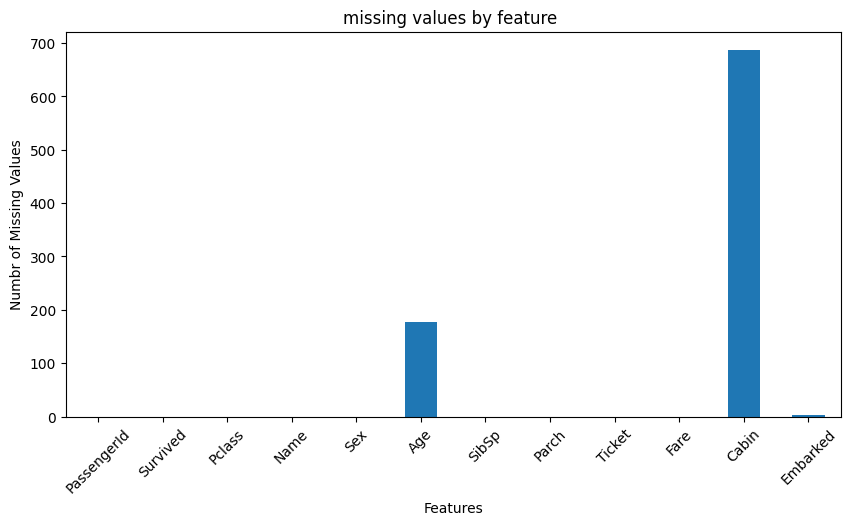

duplicate rows 0


In [5]:
#misssing values reduction
missing=df.isnull().sum()
print(missing)

missing_percent=(df.isnull().sum()/ len(df))*100
print(missing_percent)

missing_table=pd.DataFrame({'Missing Values':missing, 'Missing Percent':missing_percent})
print(missing_table)

plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar')
plt.title("missing values by feature ")
plt.xlabel("Features")
plt.ylabel("Numbr of Missing Values")
plt.xticks(rotation=45)
plt.show()
print("duplicate rows", df.duplicated().sum())
df_mean=df.copy()

In [10]:
df_mean = df.copy()

mean_age = df_mean['Age'].mean()

df_mean['Age']=df_mean['Age'].fillna(mean_age)

print("Remaining missing Age values:", df_mean['Age'].isnull().sum())

df_median=df.copy()

median_age = df_median['Age'].median()

df_median['Age']=df_median['Age'].fillna(median_age)

print("Remaining missing Age values:", df_median['Age'].isnull().sum())

df_mode = df.copy()

mode_embarked = df_mode['Embarked'].mode()[0]

df_mode['Embarked'] = df_mode['Embarked'].fillna(mode_embarked)

print("Remaining missing Embarked values:", df_mode['Embarked'].isnull().sum())

print("Mean:",mean_age)
print("Median:",median_age)


Remaining missing Age values: 0
Remaining missing Age values: 0
Remaining missing Embarked values: 0
Mean: 29.69911764705882
Median: 28.0


In [11]:
#Encoding - One-Hot

print(df[['Sex','Embarked']].head(10))

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
sparse_output=False,
handle_unknown='ignore'
)

encoded = encoder.fit_transform(df[['Sex','Embarked']])

encoded_df = pd.DataFrame(
encoded,
columns=encoder.get_feature_names_out(['Sex','Embarked'])
)

print(encoded_df.head())


#Encoding - Label
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Survived_encoded'] = le.fit_transform(df['Survived'])

print(df[['Survived','Survived_encoded']].head())

      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan
0         0.0       1.0         0.0         0.0         1.0           0.0
1         1.0       0.0         1.0         0.0         0.0           0.0
2         1.0       0.0         0.0         0.0         1.0           0.0
3         1.0       0.0         0.0         0.0         1.0           0.0
4         0.0       1.0         0.0         0.0         1.0           0.0
   Survived  Survived_encoded
0         0                 0
1         1                 1
2         1                 1
3         1                 1
4         0                 0


In [12]:
#min-max scaling
features=df[['Age','Fare']].dropna()
print(features.describe())
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
scaled_minmax=minmax.fit_transform(features)

minmax_df=pd.DataFrame(
scaled_minmax,
columns=['Age','Fare']
)

print(minmax_df.head())

#Standardisation
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()
scaled_standard= standard.fit_transform(features)

standard_df =pd.DataFrame(
scaled_standard,
columns=['Age','Fare']
)
print(standard_df.head())

              Age        Fare
count  714.000000  714.000000
mean    29.699118   34.694514
std     14.526497   52.918930
min      0.420000    0.000000
25%     20.125000    8.050000
50%     28.000000   15.741700
75%     38.000000   33.375000
max     80.000000  512.329200
        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713
        Age      Fare
0 -0.530377 -0.518978
1  0.571831  0.691897
2 -0.254825 -0.506214
3  0.365167  0.348049
4  0.365167 -0.503850
